In [25]:
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
import torch

In [26]:
A=torch.tensor([0.0,0.0])
B=torch.tensor([0.0,-100.0])
C=torch.tensor([50.0*np.sqrt(3),-150.0],dtype=torch.float32)
D=torch.tensor([100.0*np.sqrt(3),-100.0],dtype=torch.float32)
E=torch.tensor([100.0*np.sqrt(3),0.0],dtype=torch.float32)
F=torch.tensor([50.0*np.sqrt(3),50.0],dtype=torch.float32)
receivers=torch.stack([A,B,C,D,E,F],dim=0)


In [27]:
def distance(receivers,source):
    return torch.sqrt(torch.sum((receivers-source)**2,dim=1))

In [28]:
source=torch.tensor([300.0, 400.0],dtype=torch.float32)
dists=distance(receivers,source)
print(dists)

tensor([500.0000, 583.0952, 589.9479, 515.8265, 419.6152, 409.9250])


In [273]:
def difference(dists):
    n = dists.shape[0]
    ref_dist = torch.zeros(n * (n - 1) // 2, dtype=torch.float32)  # 存储差值的数组
    index = 0  # 用来索引差值
    for i in range(n):
        for j in range(i + 1, n):
            ref_dist[index] = torch.abs(dists[i] - dists[j])  # 计算差值的绝对值
            index += 1
    return ref_dist
ref_dist=difference(dists)
print(ref_dist)

tensor([ 83.0952,  89.9479,  15.8265,  80.3848,  90.0750,   6.8527,  67.2687,
        163.4800, 173.1703,  74.1214, 170.3326, 180.0229,  96.2112, 105.9015,
          9.6903])


In [402]:
def tau_generator(ref_dist, c=343.0, noise_std=0.01):
    taus=torch.zeros_like(ref_dist)
    for i in range(ref_dist.shape[0]):
        taus[i]=ref_dist[i]/c
    taus+=torch.normal(0,noise_std,taus.shape)
    return taus


In [391]:
#随机取三个传感器的时延数据,也就是丢弃12个数据,也即丢弃时延数据集的80%
def dropout_layer(X,y, dropout, seed=None,mask=None):
    assert 0.0 <= dropout <= 1.0
    if dropout == 1.0:
        return torch.zeros_like(X),torch.zeros_like(y)
    if dropout == 0.0:
        return X,y
    else:
        if seed is not None:
            torch.manual_seed(seed)  
        n_drop = int(dropout * X.numel())  
        drop_idx = torch.randperm(X.numel())[:n_drop]
        
        mask = torch.ones_like(X)
        mask.view(-1)[drop_idx] = 0  
        
        return mask * X,mask*y


real_tau_dropout,ref_dist_dropout=dropout_layer(real_tau,ref_dist,dropout=0.8)

print(real_tau_dropout * 343.0)
print(ref_dist_dropout)

tensor([  0.0000,   0.0000,  -0.0000,   0.0000,   0.0000,  37.2688,  90.0822,
          0.0000, 219.5938,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000])
tensor([  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   6.8527,  67.2687,
          0.0000, 173.1703,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000])


In [407]:
Source_suspect_1=torch.tensor([100.0,50.0],dtype=torch.float32,requires_grad=True)
loss=torch.nn.MSELoss()
trainer=torch.optim.Adam([Source_suspect_1],lr=0.2)
num_epochs=15000
dropout=0.7
noise_std=0.01
real_tau=tau_generator(difference(dists),noise_std=noise_std)
from tqdm import tqdm
for epoch in tqdm(range(num_epochs)):
    dist,real_dist=dropout_layer(difference(distance(receivers,Source_suspect_1)),real_tau*343.0,dropout=dropout)
    
    l=loss(dist,real_dist)

    trainer.zero_grad()
    l.backward()
    trainer.step()

Source_suspect_2=torch.tensor([100.0,50.0],dtype=torch.float32,requires_grad=True)
optimizer=torch.optim.Adam([Source_suspect_2],lr=0.2)
for epoch in tqdm(range(num_epochs)):
    dist,real_dist=dropout_layer(difference(distance(receivers,Source_suspect_2)),real_tau*343.0,dropout=0.0)
    
    l=loss(dist,real_dist)

    optimizer.zero_grad()
    l.backward()
    optimizer.step()

100%|██████████| 15000/15000 [00:13<00:00, 1100.49it/s]


In [416]:

print('Estimated Source Position:', Source_suspect_1.data)
print('rmse:',torch.sqrt(torch.sum((Source_suspect_1.data - source)**2)).item())
print('Estimated Source Position without dropout:', Source_suspect_2.data)
print('rmse without dropout:',torch.sqrt(torch.sum((Source_suspect_2.data - source)**2)).item())

Estimated Source Position: tensor([278.7040, 348.8766])
rmse: 55.381622314453125
Estimated Source Position without dropout: tensor([285.6948, 362.9576])
rmse without dropout: 39.708675384521484


在这里发现了一个很有意思的现象,随着dropout和noise_std的变化,rmse会发生非常明显的变化

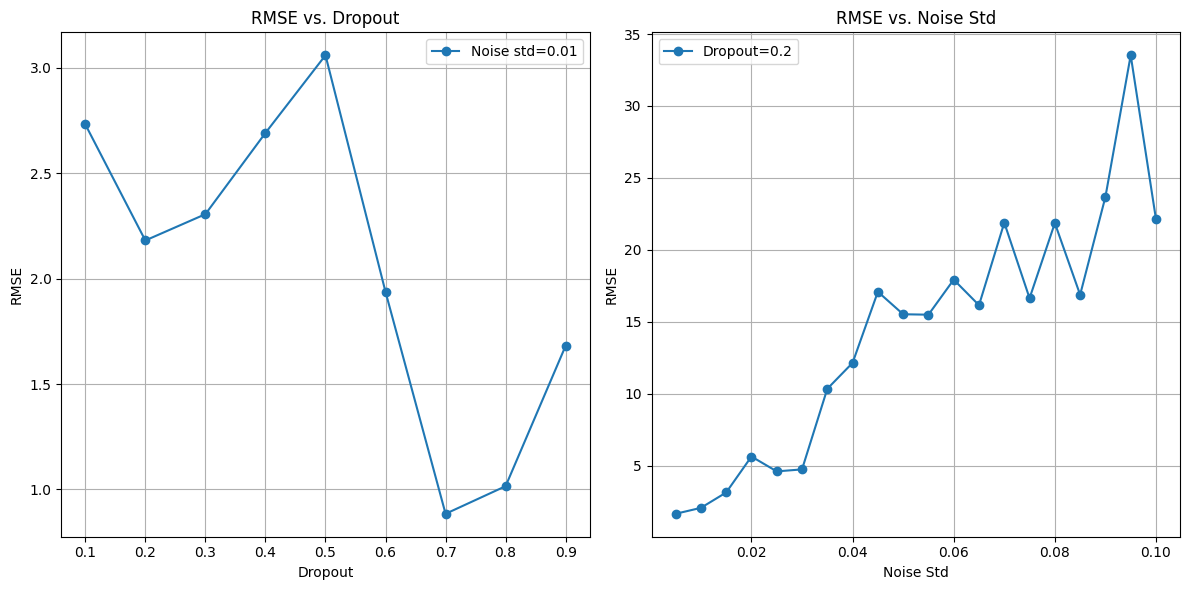

In [ ]:
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# 假设已经有 distance, dropout_layer 和 tau_generator 等相关函数

# 固定 noise_std 变化 dropout
def evaluate_with_fixed_noise_std(dropout_range, fixed_noise_std, num_epochs=15000):
    rmse_values = []
    for dropout in dropout_range:
        Source_suspect_1 = torch.tensor([100.0, 50.0], dtype=torch.float32, requires_grad=True)
        loss = torch.nn.MSELoss()
        trainer = torch.optim.Adam([Source_suspect_1], lr=0.2)
        
        # 设置固定的噪声标准差
        real_tau = tau_generator(difference(dists), noise_std=fixed_noise_std)
        
        # 训练模型并计算RMSE
        for epoch in range(num_epochs):
            dist, real_dist = dropout_layer(difference(distance(receivers, Source_suspect_1)), real_tau * 343.0, dropout=dropout)
            l = loss(dist, real_dist)
            trainer.zero_grad()
            l.backward()
            trainer.step()

        # 计算 RMSE
        rmse = torch.sqrt(torch.mean((dist - real_dist) ** 2)).item()
        rmse_values.append(rmse)

    return rmse_values

# 固定 dropout 变化 noise_std
def evaluate_with_fixed_dropout(noise_std_range, fixed_dropout, num_epochs=15000):
    rmse_values = []
    for noise_std in noise_std_range:
        Source_suspect_1 = torch.tensor([100.0, 50.0], dtype=torch.float32, requires_grad=True)
        loss = torch.nn.MSELoss()
        trainer = torch.optim.Adam([Source_suspect_1], lr=0.2)
        
        # 设置固定的 dropout
        real_tau = tau_generator(difference(dists), noise_std=noise_std)
        
        # 训练模型并计算RMSE
        for epoch in range(num_epochs):
            dist, real_dist = dropout_layer(difference(distance(receivers, Source_suspect_1)), real_tau * 343.0, dropout=fixed_dropout)
            l = loss(dist, real_dist)
            trainer.zero_grad()
            l.backward()
            trainer.step()

        # 计算 RMSE
        rmse = torch.sqrt(torch.mean((dist - real_dist) ** 2)).item()
        rmse_values.append(rmse)

    return rmse_values

# 1. 固定 noise_std 变化 dropout
dropout_range = [i * 0.1 for i in range(0, 10)]  # 0.1 到 1.0 的 dropout 范围
fixed_noise_std = 0.01
rmse_dropouts = evaluate_with_fixed_noise_std(dropout_range, fixed_noise_std)

# 2. 固定 dropout 变化 noise_std
noise_std_range = [i * 0.005 for i in range(1, 21)]  # 0.005 到 0.1 的 noise_std 范围
fixed_dropout = 0.2
rmse_noise_std = evaluate_with_fixed_dropout(noise_std_range, fixed_dropout)

# 绘制 RMSE 曲线
plt.figure(figsize=(12, 6))

# 绘制 dropout 与 RMSE 的关系
plt.subplot(1, 2, 1)
plt.plot(dropout_range, rmse_dropouts, marker='o', label=f'Noise std={fixed_noise_std}')
plt.title('RMSE vs. Dropout')
plt.xlabel('Dropout')
plt.ylabel('RMSE')
plt.grid(True)
plt.legend()

# 绘制 noise_std 与 RMSE 的关系
plt.subplot(1, 2, 2)
plt.plot(noise_std_range, rmse_noise_std, marker='o', label=f'Dropout={fixed_dropout}')
plt.title('RMSE vs. Noise Std')
plt.xlabel('Noise Std')
plt.ylabel('RMSE')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
